In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

`FinanceDataReader` 라이브러리 설치하고 import 한다.

FinanceDataReader는 한국과 미국을 비롯한 글로벌 금융 시장의 주식, 지수, 암호화폐 등 다양한 금융 데이이터와 종목 리스팅을 손쉽게 수집하고 분석할 수 있도록 도와주는 파이썬 오픈소스 라이브러리로 복잡한 웹 클롤링이나 API 인증 과정 없이 몇 줄의 코드로 다양한 거래소의 데이터를 판다스 데이터프레임 형태로 바로 가져올 수 있어, 주가 분석이나 퀀트 투자 등에 널리 쓰이고 있다.

!pip install finance-DataReader

In [2]:
import FinanceDataReader as fdr

FinanceDataReader에서 제공하는 종목 리스는 거래소 및 시장별로 세분화되어 있고 거래소 정보를 얻어오는 메소드는 `fdr.StockListing('시장키워드')`이며, 판다스 데이터프레임 형태로 결과를 리턴한다.

## 한국 시장 전 종목 및 특수 리스트  
fdr.StockListing(`'KRX'`) # `KRX 전체`(코스피 + 코스닥 + 코넥스)  
fdr.StockListing(`'KOSPI'`) # `코스피`  
fdr.StockListing(`'KOSDAQ'`) # `코스닥`  
fdr.StockListing(`'KONEX'`) # `코넥스`  
fdr.StockListing(`'KRX-DELISTING'`) # `상장폐지 종목`  
fdr.StockListing(`'KRX-ADMINISTRATIVE'`) # `관리종목`  
fdr.StockListing(`'KRX-MARCAP'`) # `시가총액 순 정렬`

## 미국 시장 및 주요 지수 구성 종목
fdr.StockListing(`'S&P500'`) # `S&P 500`  
fdr.StockListing(`'NASDAQ'`) # `나스닥 거래소`  
fdr.StockListing(`'NYSE'`) # `뉴욕 증권 거래소`  
fdr.StockListing(`'AMEX'`) # `아멕스 거래소`

## 글로벌 해외 주요 거래소
fdr.StockListing(`'SSE'`) # `상해(중국)`  
fdr.StockListing(`'SZSE'`) # `심천(중국)`  
fdr.StockListing(`'HKEX'`) # `홍콩`  
fdr.StockListing(`'TSE'`) # `도쿄(일본)`  
fdr.StockListing(`'HOSE'`) # `호치민(베트남)`

## ETF 리스트
fdr.StockListing(`'ETF/KR'`) # `국내 상장 ETF 전체`


In [13]:
fdr.StockListing('KRX')

,Code,ISU_CD,Name,Market,Dept,Close,ChangeCode,Changes,ChagesRatio,Open,High,Low,Volume,Amount,Marcap,Stocks,MarketId
0,005930,KR7005930003,삼성전자,KOSPI,NaN,274500,1,6500,2.43,275000,275500,266000,21669212,5874378493500,1601880338592000,5846278608,STK
1,000660,KR7000660001,SK하이닉스,KOSPI,NaN,1645000,1,52000,3.26,1695000,1697000,1626000,4340918,7191382761000,1200198955695000,730492365,STK
2,005935,KR7005931001,삼성전자우,KOSPI,NaN,195600,1,7800,4.15,191600,196200,188100,3846232,741557628200,157224637227850,802371203,STK
3,402340,KR7402340004,SK스퀘어,KOSPI,NaN,1154000,1,37000,3.31,1182000,1183000,1130000,658916,759169507500,151488227128000,131958386,STK
4,009150,KR7009150004,삼성전기,KOSPI,NaN,1558000,1,55000,3.66,1593000,1600000,1511000,968084,1504253195000,116372778368000,74693696,STK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2867,279060,KR7279060008,이노벡스,KONEX,일반기업부,115,0,0,0.00,0,0,0,0,0,1127904590,9807866,KNX
2868,223220,KR7223220005,로지스몬,KONEX,일반기업부,190,3,0,0.00,162,191,162,17676,3080661,1083554610,5702919,KNX
2869,002787,KR7002782001,진흥기업2우B,KOSPI,NaN,2895,0,0,0.00,0,0,0,0,0,853469160,294808,STK
2870,032685,KR7032681009,소프트센우,KOSDAQ,중견기업부,10860,4,2500,29.90,8270,10860,8270,10495,110717100,774991320,71362,KSQ


특정 종목에 대한 정보를 얻어오려면 `fdr.DataReader('종목코드'[, '시작일', '종료일'])` 메소드를 사용한다.

In [25]:
# 삼성전자(005930)의 상장일로 부터 현재까지
# fdr.DataReader('005930')
# 삼성전자(005930)의 2023-01-01로 부터 현재까지
# fdr.DataReader('005930', '2023-01-01')
# 삼성전자(005930)의 2025-01-01로 부터 2025-12-31까지
df = fdr.DataReader('005930', '2025-01-01', '2025-12-31')

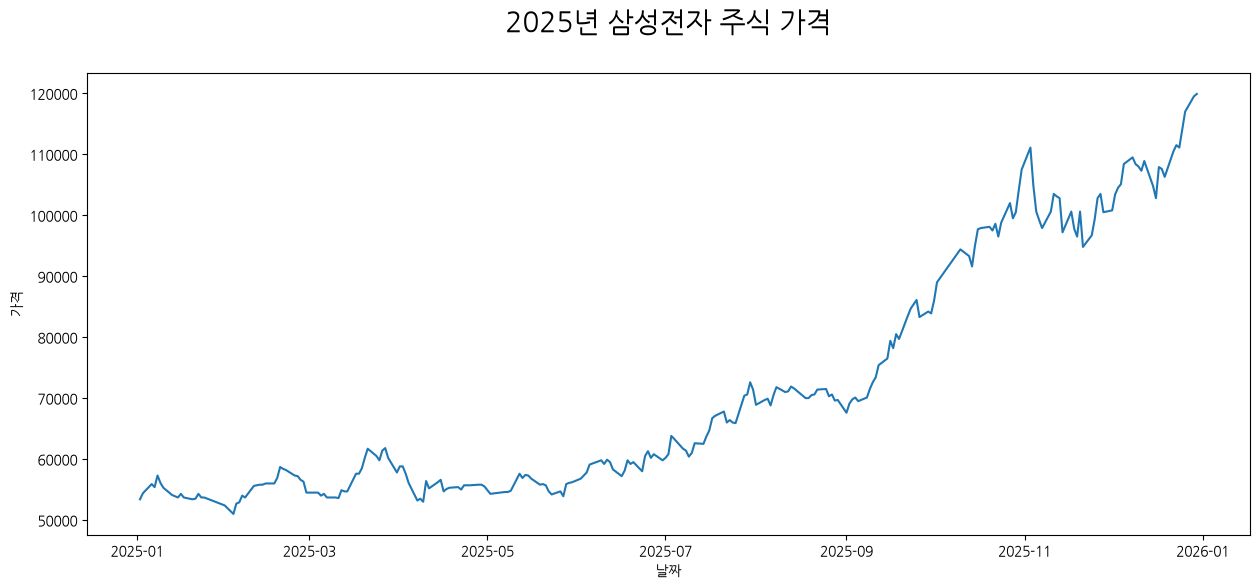

In [28]:
plt.figure(figsize=(15, 6))
sns.lineplot(x=df.index, y=df.Close)
plt.title('2025년 삼성전자 주식 가격', fontsize=20, pad=30)
plt.xlabel('날짜')
plt.ylabel('가격')
plt.show()